## Подготовительные действия

In [1]:
import sys, os
# Этот код создает виртуальный дисплей для рисования игровых изображений.
# Это не будет иметь никакого эффекта, если на вашей машине есть монитор.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import math

## Класс QLearningAgent

In [2]:
class QLearningAgent: 
    def __init__(self, alpha, epsilon, discount, get_legal_actions): 
        """ 
        Q-Learning Agent 
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html 
        Переменные экземпляра, к которым у вас есть доступ 
           - self.epsilon (исследование) 
           - self.alpha (скорость обучения) 
           - self.discount (дисконт, она же гамма) 
         Функции, которые вы должны использовать 
           - self.get_legal_actions(state) {состояние, хешируемое -> список действий, каждое из которых 
хешируемое} 
             который возвращает разрешенные действия для состояния 
           - self.get_qvalue (состояние, действие) 
             который возвращает Q (состояние, действие) 
           - self.set_qvalue (состояние, действие, значение) 
             который устанавливает Q (состояние, действие): = значение 
         !!!Важно!!! 
         Примечание: пожалуйста, избегайте прямого использования self._qValues. 
             Для этого есть специальный self.get_qvalue/set_qvalue. 
        """ 
        self.get_legal_actions = get_legal_actions 
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0)) 
        self.alpha = alpha 
        self.epsilon = epsilon 
        self.discount = discount 

    def get_qvalue(self, state, action): 
        """ Возвращает Q(state,action) """ 
        return self._qvalues[state][action] 
    
    def set_qvalue(self, state, action, value): 
        """ Устанавливает Qvalue для [state,action] в определенное значение """ 
        self._qvalues[state][action] = value 

    #---------------------ВЫ НАЧИНАЕТЕ ДОБАВЛЯТЬ СВОЙ КОД С ЭТОГО МЕСТА---------------------# 
    def get_value(self, state): 
        """ 
        Вычислите оценку вашего агента V (s), используя текущие значения q. 
         V(s) = max_over_action Q(состояние,действие) по возможным действиям. 
         Примечание: обратите внимание, что значения q могут быть отрицательными. 
        """ 
        possible_actions = self.get_legal_actions(state) 
        # If there are no legal actions, return 0.0 
        if len(possible_actions) == 0: 
            return 0.0 
        
        value = max(self.get_qvalue(state, a) for a in possible_actions)
        return value 
    

    def update(self, state, action, reward, next_state): 
        """ 
        Необходимо обновить значение Q-Value: 
           Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * V(s')) 
        """ 
        # agent parameters 
        gamma = self.discount 
        learning_rate = self.alpha 

        old_q = self.get_qvalue(state, action)
        target = reward + gamma * self.get_value(next_state)
        new_q = (1.0 - learning_rate) * old_q + learning_rate * target
 
        self.set_qvalue(state, action, new_q) 


    def get_best_action(self, state): 
        """ 
        Вычислите наилучшее действие для состояния (используя текущие значения q). 
        """ 
        possible_actions = self.get_legal_actions(state) 
        # If there are no legal actions, return None 
        if len(possible_actions) == 0: 
            return None 
        
        qvals = [self.get_qvalue(state, a) for a in possible_actions]
        best_q = max(qvals)
        best_actions = [a for a, q in zip(possible_actions, qvals) if q == best_q]
        best_action = random.choice(best_actions)

        return best_action 
    

    def get_action(self, state): 
        """ 
        Вычислите действие, которое нужно предпринять в текущем состоянии, включая 
исследование. 
         С вероятностью self.epsilon мы должны предпринять случайное действие. 
             иначе - лучшее действие политики (self.get_best_action). 
         Примечание. Чтобы выбрать случайным образом из списка, используйте random.choice(list). 
30 
 
               Чтобы выбрать True или False с заданной вероятностью, сгенерируйте универсальное число 
в [0, 1] 
               и сравните с вашей вероятностью 
        """ 
        # Pick Action 
        possible_actions = self.get_legal_actions(state) 
        action = None 
        # If there are no legal actions, return None 
        if len(possible_actions) == 0: 
            return None 
        # agent parameters: 
        epsilon = self.epsilon 

        if random.random() < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state) 
            
        return chosen_action

In [3]:
import gymnasium as gym 
env = gym.make("Taxi-v3") 
n_actions = env.action_space.n 
agent = QLearningAgent( 
    alpha=0.5, epsilon=0.25, discount=0.99, 
    get_legal_actions=lambda s: range(n_actions)) 
def play_and_train(env, agent, t_max=10**4): 
    """ 
    Эта функция должна 
     - запустить полную игру, действия заданы политикой e-greeding агента 
     - обучать агента, используя agent.update(...) всякий раз, когда это возможно 
     - вернуть общую награду 
    """ 
    total_reward = 0.0 
    s, _ = env.reset()
    for _ in range(t_max):
        a = agent.get_action(s)
        step_out = env.step(a)
        
        if len(step_out) == 5:
            next_s, r, terminated, truncated, _ = step_out
            done = terminated or truncated
        else:
            next_s, r, done, _ = step_out

        agent.update(s, a, r, next_s)

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

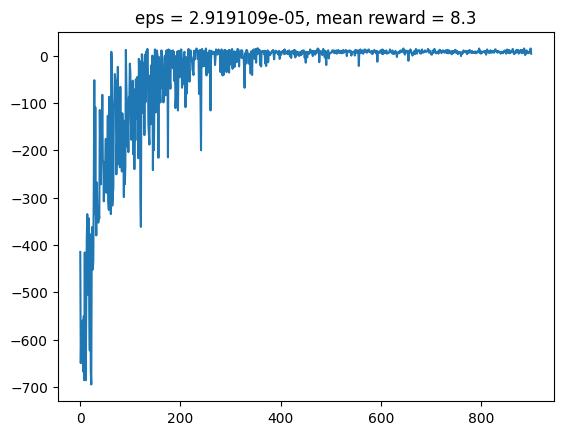

In [4]:
from IPython.display import clear_output 
rewards = [] 
for i in range(1000): 
    rewards.append(play_and_train(env, agent)) 
    agent.epsilon *= 0.99 
    if i % 100 == 0: 
        clear_output(True) 
        plt.title('eps = {:e}, mean reward = {:.1f}'.format(agent.epsilon, np.mean(rewards[-10:]))) 
        plt.plot(rewards) 
        plt.show()

## Бинаризованные пространства состояний

first state: [-0.04958522  0.02551407 -0.04705565 -0.01049527]


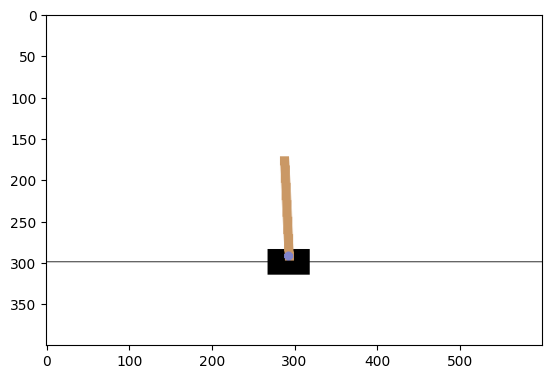

In [5]:
def make_env():
    return gym.make('CartPole-v1', render_mode='rgb_array')
env = make_env()
obs, info = env.reset()
print("first state: %s" % obs)
plt.imshow(env.render())

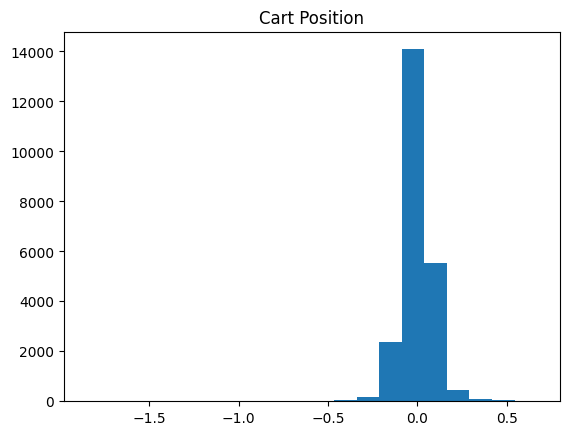

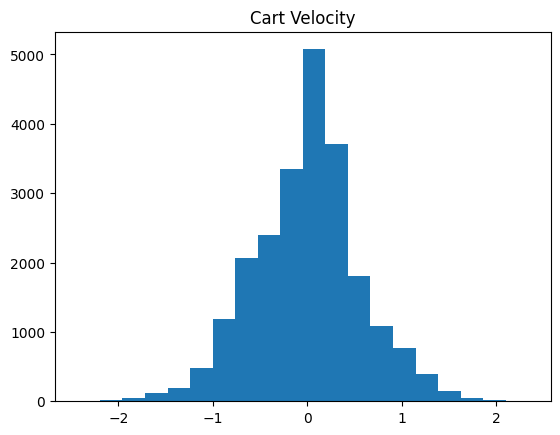

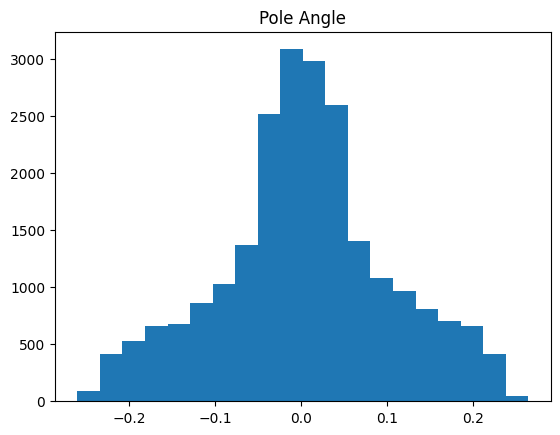

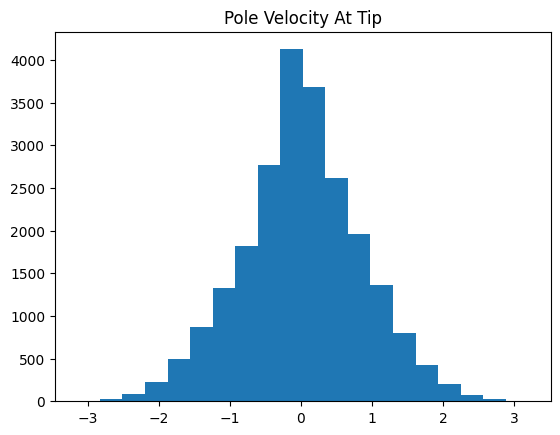

In [6]:
seen_observations = []

for _ in range(1000):
    s = env.reset()

    if isinstance(s, tuple) and len(s) == 2:
        s, _ = s
    seen_observations.append(s)

    done = False
    while not done:
        step_out = env.step(env.action_space.sample())

        if len(step_out) == 5:
            s, r, terminated, truncated, _ = step_out
            done = terminated or truncated
        else:
            s, r, done, _ = step_out

        seen_observations.append(s)

seen_observations = np.array(seen_observations)

labels = [
    "Cart Position",
    "Cart Velocity",
    "Pole Angle",
    "Pole Velocity At Tip"
]

for obs_i in range(env.observation_space.shape[0]):
    plt.hist(seen_observations[:, obs_i], bins=20)
    plt.title(labels[obs_i])
    plt.show()

## Базированная среда

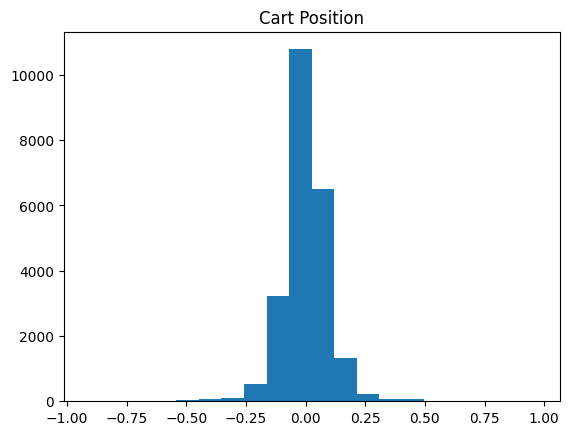

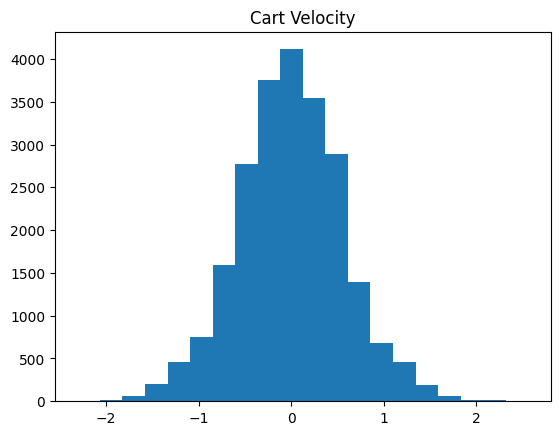

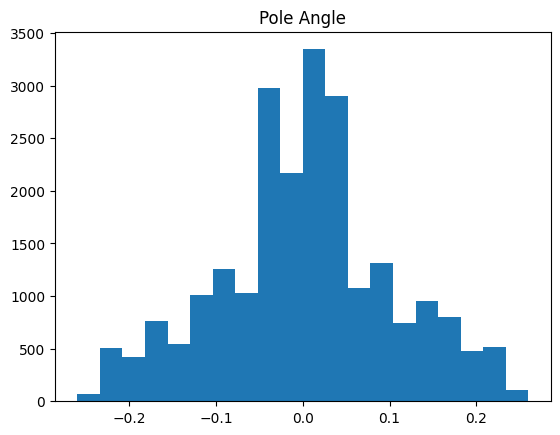

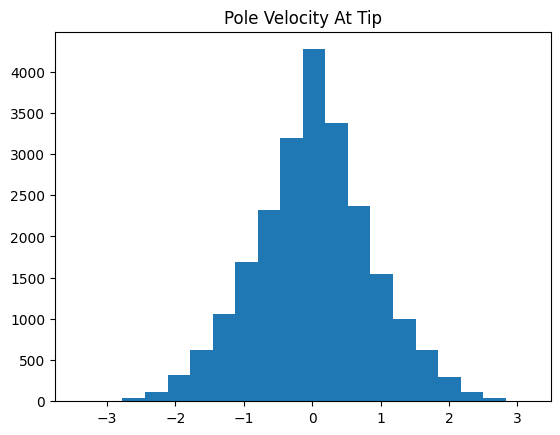

In [7]:
from gymnasium import ObservationWrapper
class Binarizer(ObservationWrapper): 
    def observation(self, state): 
        # Hint: Используйте round(x, n_digits). 
        # Вы можете выбрать разные n_digits для каждого измерения.. 
        state = [round(x, 2) for x in state]
        return tuple(state)
env2 = Binarizer(gym.make("CartPole-v1"))

seen_observations = []

for _ in range(1000):
    s, _ = env2.reset()
    seen_observations.append(s)

    done = False
    while not done:
        s, r, terminated, truncated, _ = env2.step(env2.action_space.sample())
        done = terminated or truncated
        seen_observations.append(s)

seen_observations = np.array(seen_observations)

for obs_i in range(env2.observation_space.shape[0]):
    plt.hist(seen_observations[:, obs_i], bins=20)
    plt.title(labels[obs_i])
    plt.show()